# Load a LangGraph from YAML

This notebook reads `graph.yaml` and dynamically builds a `StateGraph` from it.

Each YAML node defines:
- `name` — node id
- `system_prompt` — instruction sent to the LLM
- `input_key` — state field read as the human message
- `output_key` — state field where the LLM response is stored

Edges (including `START` and `END`) are also declared in the YAML.

In [1]:
from pathlib import Path
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
load_dotenv(env_path)  # Load environment variables from workspace root .env file

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)


In [2]:
import yaml
from pathlib import Path

yaml_path = Path.cwd() / "graph.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    graph_spec = yaml.safe_load(f)

print("State fields:", list(graph_spec["state"].keys()))
print("Nodes:", [n["name"] for n in graph_spec["nodes"]])
print("Edges:", [(e["from"], e["to"]) for e in graph_spec["edges"]])

State fields: ['topic', 'outline', 'draft', 'final']
Nodes: ['outline', 'draft', 'edit']
Edges: [('START', 'outline'), ('outline', 'draft'), ('draft', 'edit'), ('edit', 'END')]


## Build the State schema dynamically

`TypedDict` is created at runtime from the `state` section of the YAML. We map the
string type names (`str`, `int`, ...) to actual Python types.

In [3]:
from typing_extensions import TypedDict

TYPE_MAP = {"str": str, "int": int, "float": float, "bool": bool, "list": list, "dict": dict}

annotations = {k: TYPE_MAP[v] for k, v in graph_spec["state"].items()}
GraphState = TypedDict("GraphState", annotations)

print(GraphState.__annotations__)

{'topic': <class 'str'>, 'outline': <class 'str'>, 'draft': <class 'str'>, 'final': <class 'str'>}


## Factory: turn a YAML node spec into a callable LangGraph node

Each node:
1. Reads `state[input_key]` as the user message
2. Sends it to the LLM with the configured `system_prompt`
3. Returns `{output_key: response.content}` to update the state

In [4]:
def make_llm_node(system_prompt: str, input_key: str, output_key: str):
    """Return a LangGraph node function configured from the YAML spec."""
    def _node(state: dict) -> dict:
        user_text = str(state.get(input_key, ""))
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_text),
        ])
        return {output_key: response.content}
    _node.__name__ = f"node_{output_key}"
    return _node

## Assemble and compile the graph from the YAML spec

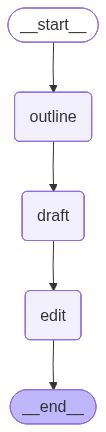

In [5]:
from langgraph.graph import StateGraph, START, END

NAME_TO_TERMINAL = {"START": START, "END": END}

def build_graph_from_spec(spec: dict, state_schema):
    builder = StateGraph(state_schema)

    # Register every node defined in YAML
    for node in spec["nodes"]:
        builder.add_node(
            node["name"],
            make_llm_node(node["system_prompt"], node["input_key"], node["output_key"]),
        )

    # Wire edges; START / END are resolved to LangGraph sentinels
    for edge in spec["edges"]:
        src = NAME_TO_TERMINAL.get(edge["from"], edge["from"])
        dst = NAME_TO_TERMINAL.get(edge["to"], edge["to"])
        builder.add_edge(src, dst)

    return builder.compile()

graph = build_graph_from_spec(graph_spec, GraphState)
graph

## Run the graph

In [6]:
initial_state = {"topic": "How vector databases power retrieval-augmented generation"}

result = graph.invoke(initial_state)

for key in graph_spec["state"]:
    print(f"--- {key} ---")
    print(result.get(key, ""))
    print()

--- topic ---
How vector databases power retrieval-augmented generation

--- outline ---
1. Store and index high-dimensional vectors for efficient similarity searches.  
2. Enable rapid retrieval of contextually relevant data to augment generative models.  
3. Enhance accuracy by integrating real-time, domain-specific knowledge into outputs.

--- draft ---
This system leverages advanced vector storage and indexing techniques to efficiently manage high-dimensional data, enabling rapid similarity searches even at scale. By quickly retrieving contextually relevant information, it augments generative models with targeted knowledge, ensuring outputs align with specific use cases. Real-time integration of domain-specific insights further sharpens accuracy, allowing models to adapt dynamically to specialized requirements. Together, these capabilities optimize performance, relevance, and precision in AI-driven applications.

--- final ---
This system employs advanced vector storage and indexin